In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=10000,n_features=3,n_redundant=1,n_classes=2)
X,y

(array([[ 0.94903336,  0.97270581,  1.43061148],
        [-1.16773862,  1.98795561,  0.8224716 ],
        [ 0.22243196,  0.37995578,  0.4585493 ],
        ...,
        [-0.99662975,  1.3955847 ,  0.45779404],
        [ 0.47010097,  0.48555606,  0.7116734 ],
        [ 1.32159666,  1.28801626,  1.93826232]], shape=(10000, 3)),
 array([1, 0, 1, ..., 0, 1, 1], shape=(10000,)))

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)
X_train[:,0].shape,y_train.shape

((7500,), (7500,))

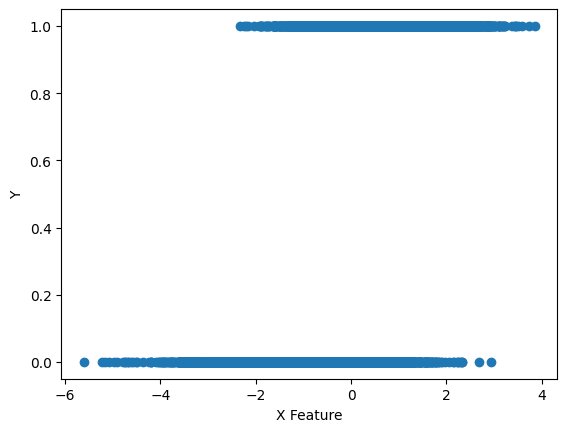

In [15]:
plt.scatter(X_train[:,2],y_train)
plt.xlabel("X Feature")
plt.ylabel("Y")
plt.show()

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
logistic = LogisticRegression()
logistic.fit(X_train,y_train)
y_pred = logistic.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9488
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1245
           1       0.95      0.95      0.95      1255

    accuracy                           0.95      2500
   macro avg       0.95      0.95      0.95      2500
weighted avg       0.95      0.95      0.95      2500



In [26]:
param_grid = {
    "solver":["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"],
    "penalty":["l1","l2","elasticnet","None"],
    "C":[0.01,0.1,1.0,10,1000]
}

In [27]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=logistic,param_grid=param_grid)

In [28]:
grid.fit(X_train,y_train)
y_pred = grid.predict(X_test)

c:\Users\gnana\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gnana\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [33]:
grid.best_params_

{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}

In [31]:
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.948
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1245
           1       0.95      0.95      0.95      1255

    accuracy                           0.95      2500
   macro avg       0.95      0.95      0.95      2500
weighted avg       0.95      0.95      0.95      2500

